### Directed Graph

A directed graph $G$ is defined by:

- A set of nodes (entities)
$$
N = \{1,2,3,4\}
$$

- A set of edges (pointers)
$$
E = \{(1,2), (1,3), (3,2), (3,4), (4,3)\}
$$

This graph is **cyclic**.

---

### Transaction Concept

#### Atomic Database Actions

- $R(x)$ : read data element $x$  
- $W(x)$ : write data element $x$

A **data element** can be:
- attribute
- tuple
- block
- table

---

#### Transaction

A **transaction** is a collection of atomic database actions that are executed as **one logical unit**, with respect to:

- concurrency
- recovery

---

### Precedence Graph

**Definition:** A precedence graph $G(S)$ is a directed graph connected to a schedule $S$ such that:

- The set of nodes is the set of transactions in $S$.

- There exists an edge
$$
T_i \rightarrow T_j
$$

in $G$ if there is a **conflicting pair of operations** $o_i, o_j$ in $S$ such that

$$
o_i \text{ occurs before } o_j.
$$

### Serializability Theorem

**Theorem**

A schedule $S$ is **serializable** if and only if the precedence graph $G(S)$ is **A-cyclic**.

$$
S \text{ is serializable } \iff G(S) \text{ is A-cyclic}
$$

---

### ACID Properties

A transaction satisfies the **ACID properties**:

- **Atomicity**  
A transaction runs either completely (**commit**) or not at all (**abort**).

- **Consistency preservation**  
A transaction must respect the database integrity constraints; otherwise it must be aborted.

- **Isolation**  
Each transaction executes without visible interference from other transactions.

- **Durability**  
After a transaction commits, the persistence of the updated data is guaranteed.

---

### Conflicting Operations and Schedule Equivalence

- **Intuition:**  
Two atomic database actions are **conflicting** if reversing their execution order produces effects that are visible to the outside world.

- **Definition:**  
Two atomic database actions are **conflicting** if:
  - they affect the same data element, and
  - at least one of the operations is a **write**.

- **Definition:**  
Two schedules are **equivalent** if they order all **conflicting operations** in the same way.

---

### Conflict Serializability Example

#### Schedules $S5$ and $S6$

$$
S5
$$

$$
\begin{array}{c|c|c}
T1 & T2 & T3 \\
\hline
 &  & W(x) \\
R(x) &  &  \\
 &  & R(z) \\
 & W(x) &  \\
W(y) &  &  \\
 & W(y) &
\end{array}
$$

$$
S6
$$

$$
\begin{array}{c|c|c}
T1 & T2 & T3 \\
\hline
 &  & W(x) \\
 &  & R(z) \\
R(x) &  &  \\
W(y) &  &  \\
 & W(x) &  \\
 & W(y) &
\end{array}
$$

We compare schedules $S5$ and $S6$.

- $S6$ is **serial**, with transaction order
$$
T_3 \rightarrow T_1 \rightarrow T_2
$$

- In $S5$ the operations are interleaved, but we examine the **conflicts**.

Conflicting operations give the following precedence relations:

$$
T_3 \rightarrow T_1
$$

(because $W_3(x)$ occurs before $R_1(x)$)

$$
T_3 \rightarrow T_2
$$

(because $W_3(x)$ occurs before $W_2(x)$)

$$
T_1 \rightarrow T_2
$$

(because $W_1(y)$ occurs before $W_2(y)$)

Thus the **precedence graph** implies the order

$$
T_3 \rightarrow T_1 \rightarrow T_2
$$

which is exactly the same order as the serial schedule $S6$.

Therefore:

- $S5$ and $S6$ order all conflicts the same way  
- $S5$ is **equivalent** to $S6$  
- since $S6$ is serial, $S5$ is **conflict-serializable (correct)**.

---

**Conflict-serializability bepalen**

1. **Maak de precedence graph:**  
   Elke transactie is een knoop. Trek een pijl  
   $$
   T_i \rightarrow T_j
   $$  
   als een operatie van $T_i$ conflicteert met een latere operatie van $T_j$ op hetzelfde data-item.

2. **Controleer op cycli:**  
   Als de graaf een cykel bevat, is het schedule **niet conflict-serializable**.  
   Als er geen cykel is, dan is het schedule **conflict-serializable**.

3. **Bepaal de serialisatie (topologische sortering):**  
   Kies telkens een transactie zonder inkomende pijlen (in-degree $=0$), plaats deze in de serialisatie en verwijder de knoop en zijn pijlen uit de graaf. Maak een ranglijst van knopen ($T_i$) en haar inkomende pijlen, werk van boven naar beneden. Voorbeeld;

#### S2

$$
\begin{array}{c|c|c|c|c}
T1 & T2 & T3 & T4 & T5 \\ \hline
   &    &    &    & w(z) \\
   &    & r(y) &  &     \\
w(x)&   &      &  &     \\
   &    &      & r(z) & \\
   &    & r(x) &     & \\
   &    &      &     & w(x) \\
   & w(z) &    &     & \\
   & w(y) &    &     &
\end{array}
$$

We zien

$$
    T_5 \rightarrow T_4, \\
    T_5 \rightarrow T_2, \\
    T_3 \rightarrow T_2, \\
    T_1 \rightarrow T_3, \\
    T_1 \rightarrow T_5, \\
    T_4 \rightarrow T_2, \\
    T_3 \rightarrow T_5
$$

#### Presedence graph G(S2)

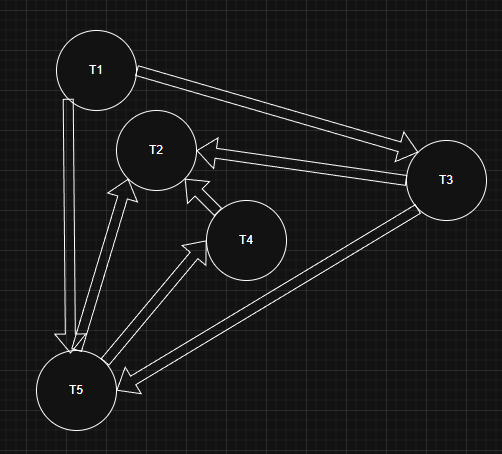

We zien dat $G(S2)$ niet cyclisch is en dus serializable, 

We bepalen de serial volgorde via topological sort, we maken een ranglijst van de inkomende pijlen in elke knoop

$$
T_1:0,\quad
T_3:1,\quad
T_4:1,\quad
T_5:2,\quad
T_2:3
$$

Kies eerst de knoop met $0$ inkomende pijlen:

$$
T_1
$$

Verwijder de pijlen van $T_1$:

$$
T_3:0,\quad
T_5:1,\quad
T_4:1,\quad
T_2:3
$$

Kies vervolgens:

$$
T_3
$$

Verwijder de pijlen van $T_3$:

$$
T_5:0,\quad
T_4:1,\quad
T_2:2
$$

Kies daarna:

$$
T_5
$$

Verwijder de pijlen van $T_5$:

$$
T_4:0,\quad
T_2:1
$$

Kies vervolgens:

$$
T_4
$$

Verwijder de pijlen van $T_4$:

$$
T_2:0
$$

Tot slot:

$$
T_2
$$

Dus de serial volgorde is:

$$
T_1,\, T_3,\, T_5,\, T_4,\, T_2
$$

$$
\begin{array}{c|c|c|c|c}
T1 & T2 & T3 & T4 & T5 \\ \hline
w(x)&   &      &    &  \\
   &    & r(y) &  &     \\
   &    & r(x) &  &     \\
   &    &      &  &w(z) \\
   &    &      &     & w(x) \\
   &    &      & r(z)    &  \\
   & w(z) &    &     & \\
   & w(y) &    &     &
\end{array}
$$